### Architectural design
I will test a pipeline where the algo will work on a aggregating news to create a story.
1. Scrape multiple articles
2. Embed the content of the articles
3. Cluster the embeddings
4. Summarize the story

Definition of a story : A summarized text from the group of news items (a group being a cluster)

#### 1. Simulating the scarping of multiple articles

In [1]:
"""
Test articles for clustering / embedding experiments.

Layout: 4 expected story clusters, ~19 articles total.
Each article is a dict with:
  - "id":      short stable identifier
  - "url":     original source URL
  - "cluster": expected cluster label (ground truth for evaluation)
  - "title":   article title
  - "content": first ~300 words of the article body (cleaned of nav/boilerplate)

Notes on data sourcing:
  Most content was fetched directly from the publishers via web fetch on
  May 4, 2026. A few sources (CNBC, Washington Post, 24/7 Wall St) returned
  HTTP 403 to the fetcher; for those, content was reconstructed from public
  search-engine snippets and is shorter than 300 words. Those entries are
  flagged with "_partial_content_from_snippets": True so you can decide
  whether to re-scrape them yourself in your test pipeline.

Suggested usage:
  from test_articles import ARTICLES
  for a in ARTICLES:
      embedding = embed(a["title"] + " " + a["content"])
      ...

Then evaluate clustering by comparing predicted clusters against
the "cluster" labels.
"""

ARTICLES = [
    # ============================================================
    # CLUSTER A — Musk vs. Altman / OpenAI trial
    # ============================================================
    {
        "id": "cnbc_trial_day2",
        "url": "https://www.cnbc.com/2026/04/28/openai-trial-elon-musk-sam-altman-live-updates.html",
        "cluster": "musk_openai_trial",
        "title": "OpenAI lawsuit updates: Elon Musk v. Sam Altman trial day 2",
        "content": (
            "The first witness called to testify in the case is Musk, his lawyers confirmed. "
            "Musk's testimony will begin after a brief 20-minute recess that the judge just ordered. "
            "Microsoft is also named as a defendant in the lawsuit. Musk accuses Microsoft of aiding "
            "and abetting OpenAI, Altman and Brockman's alleged misconduct in one claim in the case. "
            "His attorneys will argue that Microsoft enabled their alleged breach of charitable trust "
            "through its investments and partnerships with the company's for-profit subsidiary. "
            "Musk said in his testimony that he was not opposed to the creation of a small for-profit "
            "subsidiary, 'as long as the tail didn't wag the dog.' Musk said he was motivated to start "
            "OpenAI to serve as a counterweight to Google. He got the idea after an argument he had with "
            "Google co-founder Larry Page, who called Musk a 'speciesist for being pro-human,' he testified. "
            "'I could have started it as a for profit and I chose not to,' Musk said on the stand. Earlier, "
            "attorneys for Musk and OpenAI presented their opening arguments to the jury. Musk's lead trial "
            "lawyer, Steven Molo, delivered the opening statement for the Tesla and SpaceX CEO. OpenAI lawyer "
            "William Savitt gave the opening statement for the AI company, Altman and Brockman. OpenAI has "
            "characterized Musk's lawsuit as a baseless 'harassment campaign.' The company said Monday in a "
            "post on X that it 'can't wait to make our case in court where both the truth and the law are on "
            "our side.' 'We are here because Mr. Musk didn't get his way at OpenAI,' Savitt told the jury. "
            "'That's what happened. He quit, saying they would fail for sure. But my clients had the nerve "
            "to go on and succeed without him.'"
        ),
        "_partial_content_from_snippets": True,
    },
    {
        "id": "cnbc_trial_day3",
        "url": "https://www.cnbc.com/2026/04/29/musk-altman-live-updates-day-3-open-ai-trial.html",
        "cluster": "musk_openai_trial",
        "title": "OpenAI lawsuit updates: Elon Musk v. Sam Altman trial day 3",
        "content": (
            "Elon Musk continued his testimony on Wednesday in the high-profile trial in his lawsuit "
            "against OpenAI CEO Sam Altman taking place in federal court in Oakland, California. Musk "
            "sued OpenAI, Altman and Greg Brockman, the company's president, two years ago, alleging "
            "they reneged on their commitments to preserve the artificial intelligence lab's nonprofit "
            "structure. Musk, who co-founded OpenAI in 2015, claims the roughly $38 million he "
            "contributed to the company was used for unauthorized commercial purposes that did not "
            "advance its charitable mission. Steven Molo, Musk's lawyer, kicked off the proceedings on "
            "Wednesday by asking Musk questions about his understanding of OpenAI's corporate structure "
            "and his relationships with OpenAI executives. Musk said he 'was a fool' for giving OpenAI "
            "and Altman the funding that was then used to create an $800 billion company. Jared Birchall, "
            "who manages Musk's family office and is also an executive at xAI and Neuralink, will be next "
            "to testify. Musk said that Microsoft's $10 billion investment in OpenAI was the key tipping "
            "point that made him believe OpenAI was violating its nonprofit mission. He said the size of "
            "that investment was too large to be a traditional donation, and that he believed Microsoft "
            "was looking for a financial return. Musk said Microsoft has its own motivations, which would "
            "be different from the motivations of the charity. 'All due respect to Microsoft, do you "
            "really want Microsoft controlling digital superintelligence?' Musk asked. After Microsoft "
            "made its donation, Musk said he asked for a legal investigation into OpenAI. Musk's lawyers "
            "have centered their arguments in the trial around two claims: breach of charitable trust "
            "and unjust enrichment. The breach of charitable trust claim is key. If the OpenAI camp is "
            "found at fault, the trial will proceed to a remedies phase."
        ),
        "_partial_content_from_snippets": True,
    },
    {
        "id": "cnbc_trial_day4",
        "url": "https://www.cnbc.com/2026/04/30/openai-trial-elon-musk-sam-altman-live-updates.html",
        "cluster": "musk_openai_trial",
        "title": "OpenAI lawsuit updates: Elon Musk v. Sam Altman trial day 4",
        "content": (
            "Elon Musk wrapped up his testimony on Thursday as the trial in his lawsuit against OpenAI "
            "CEO Sam Altman continued into its fourth day. OpenAI's attorney, William Savitt, "
            "cross-examined Musk in the morning. He asked Musk about the capped nature of Microsoft's "
            "investments in OpenAI, his involvement in negotiations about the company's structure, and "
            "whether he had ever benefited financially from his connection with the company. Lawyers from "
            "OpenAI and Microsoft wrapped their cross-examination of Musk. Musk said that his for-profit "
            "companies Tesla, SpaceX, X and Neuralink were all 'socially beneficial.' Musk sued OpenAI, "
            "Altman, and Greg Brockman, the company's president, in 2024, alleging that they went back "
            "on their commitments to keep the artificial intelligence company a nonprofit and to follow "
            "its charitable mission. He claims that the roughly $38 million he donated to seed OpenAI, a "
            "company he co-founded, was used for unauthorized commercial purposes. Once Musk wrapped up "
            "his testimony after roughly two hours of questioning on Thursday, his attorneys called Jared "
            "Birchall, who manages Musk's billions at his family office, as their next witness. Birchall "
            "testified about his knowledge of Musk's specific donations to OpenAI. Judge Yvonne Gonzalez "
            "Rogers oversaw the proceedings from federal court in Oakland, California. The trial will "
            "resume on Monday. Judge Yvonne Gonzalez Rogers is weighing a request to strike some of the "
            "testimony from Jared Birchall. OpenAI's lawyers are seeking to eliminate some of Birchall's "
            "testimony about xAI's bid to acquire OpenAI. Birchall was also questioned about any possible "
            "restrictions on Musk's donor-advised funds. OpenAI's attorney, Wilson, pressed Birchall to "
            "clarify how he became convinced that Altman was somehow inappropriately negotiating 'on both "
            "sides of the table' to restructure OpenAI."
        ),
        "_partial_content_from_snippets": True,
    },
    {
        "id": "cnbc_trial_week1_recap",
        "url": "https://www.cnbc.com/2026/05/02/musk-testimony-dominated-first-week-musk-v-altman-trial-in-oakland.html",
        "cluster": "musk_openai_trial",
        "title": "Musk testimony dominated first week of Musk v. Altman trial in Oakland",
        "content": (
            "A week into the Musk v. Altman trial, which features two towering figures in the tech "
            "industry facing off in a case that could have major implications for OpenAI, the plaintiff "
            "has made his central message clear to the jury. 'You can't just steal a charity,' Elon Musk, "
            "the world's richest person, said repeatedly during his time on the stand at a federal "
            "courthouse in Oakland, California. Musk's testimony was the centerpiece of the trial's first "
            "week. It comes two years after the Tesla and SpaceX CEO first sued OpenAI CEO Sam Altman and "
            "Greg Brockman, the company's president, alleging they went back on their promises to keep "
            "the artificial intelligence startup a nonprofit and to follow its charitable mission. Musk, "
            "who helped start OpenAI in 2015 as a nonprofit, claims that the roughly $38 million he donated "
            "to the project was used for unauthorized commercial purposes. OpenAI, now valued at over $850 "
            "billion by private investors, has called Musk's allegations 'baseless.' Musk left OpenAI's "
            "board in 2018, and five years later started xAI as a competitor, before merging that business "
            "with SpaceX in February. The trial began Monday with the seating of a nine-person jury. "
            "Attorneys for both parties presented opening arguments on Tuesday. The main event was Musk's "
            "testimony, which stretched over the course of three days, wrapping up on Thursday. The "
            "courtroom was dark on Friday, and proceedings will resume next week, with Judge Yvonne "
            "Gonzalez Rogers, an appointee of former President Barack Obama, presiding over the case. "
            "Altman and Brockman are expected to testify later this month. In a January filing, Musk's "
            "attorneys said their client should receive up to $134 billion in damages from OpenAI and "
            "Microsoft, which is also named as a defendant. Musk's team now says any 'ill-gotten gains' "
            "should be returned to OpenAI's foundation."
        ),
        "_partial_content_from_snippets": True,
    },
    {
        "id": "nbc_trial_day3",
        "url": "https://www.nbcnews.com/tech/tech-news/elon-musk-testimony-day-three-sam-altman-openai-trial-rcna342967",
        "cluster": "musk_openai_trial",
        "title": "In Musk v. Altman case, judge warns lawyers that AI itself isn't on trial",
        "content": (
            "OAKLAND, Calif. — The third day of Elon Musk's testimony in his high-stakes trial against "
            "OpenAI began with a bout of bickering over whether AI could lead to the 'extinction' of the "
            "human race. 'This is a real risk, we all could die as a result of artificial intelligence,' "
            "Musk's attorney Steven Molo said in the courtroom, in objection to Judge Yvonne Gonzalez "
            "Rogers' attempts to shut down the discussion. Rogers fired back, reminding Molo to stay "
            "focused on the issue on trial: that Musk claims OpenAI CEO Sam Altman betrayed public trust "
            "by enriching himself through the artificial intelligence company they founded together in "
            "2015 as a nonprofit venture. 'It's ironic your client, despite these risks, is creating a "
            "company that is in the exact space,' Rogers said. 'There are some people who do not want to "
            "put the future of humanity in Mr. Musk's hands … But we're not going to get into that "
            "business.' Musk's lawsuit against Altman is the culmination of a yearslong feud that has "
            "sometimes led the two former associates to trade public barbs online. Altman was in the "
            "room Wednesday and Thursday as Musk testified. The case, scheduled to run for four weeks, "
            "could define the future of OpenAI and its flagship AI model, ChatGPT. Musk demands an "
            "estimated $134 billion in damages from OpenAI and Microsoft, a co-defendant and one of "
            "OpenAI's top financial backers. He claims OpenAI benefited from his money, advice, "
            "recruiting efforts and connections. But Altman's side rebuts the credit he takes, claiming "
            "that Musk never fulfilled his $1 billion commitment to the company — which Musk also "
            "confirmed in court this week — and that he quit when Altman and fellow co-founders Greg "
            "Brockman and Ilya Sutskever refused to let him control OpenAI or absorb it into his electric "
            "car company, Tesla. Musk, who said Wednesday that he deliberately chose to create OpenAI "
            "'as a nonprofit for the public good,' launched his own for-profit AI company, xAI, in 2023."
        ),
    },
    {
        "id": "wapo_trial_recap",
        "url": "https://www.washingtonpost.com/technology/2026/05/02/musk-altman-openai-trial/",
        "cluster": "musk_openai_trial",
        "title": "Elon Musk faced OpenAI in court. So far, the case is all about him.",
        "content": (
            "OAKLAND, Calif. — Federal judge Yvonne Gonzalez Rogers had stern words for Tesla CEO Elon "
            "Musk as she prepared to open the trial in his case against ChatGPT-maker OpenAI and its "
            "chief executive Sam Altman. Elon Musk's outsize reputation, provocative remarks and his "
            "friction with a federal judge have dominated the trial in his case against ChatGPT-maker "
            "OpenAI."
        ),
        "_partial_content_from_snippets": True,
    },

    # ============================================================
    # CLUSTER B — Apple CEO transition: Cook -> Ternus
    # ============================================================
    {
        "id": "apple_press_release",
        "url": "https://www.apple.com/newsroom/2026/04/tim-cook-to-become-apple-executive-chairman-john-ternus-to-become-apple-ceo/",
        "cluster": "apple_ceo_transition",
        "title": "Tim Cook to become Apple Executive Chairman John Ternus to become Apple CEO",
        "content": (
            "CUPERTINO, CALIFORNIA Apple announced that Tim Cook will become executive chairman of "
            "Apple's board of directors and John Ternus, senior vice president of Hardware Engineering, "
            "will become Apple's next chief executive officer effective on September 1, 2026. The "
            "transition, which was approved unanimously by the Board of Directors, follows a thoughtful, "
            "long-term succession planning process. Cook will continue in his role as CEO through the "
            "summer as he works closely with Ternus on a smooth transition. As executive chairman, Cook "
            "will assist with certain aspects of the company, including engaging with policymakers around "
            "the world. 'It has been the greatest privilege of my life to be the CEO of Apple and to "
            "have been trusted to lead such an extraordinary company. I love Apple with all of my being, "
            "and I am so grateful to have had the opportunity to work with a team of such ingenious, "
            "innovative, creative, and deeply caring people who have been unwavering in their dedication "
            "to enriching the lives of our customers and creating the best products and services in the "
            "world,' said Cook. 'John Ternus has the mind of an engineer, the soul of an innovator, and "
            "the heart to lead with integrity and with honor. He is a visionary whose contributions to "
            "Apple over 25 years are already too numerous to count, and he is without question the right "
            "person to lead Apple into the future. I could not be more confident in his abilities and his "
            "character, and I look forward to working closely with him on this transition and in my new "
            "role as executive chairman.' 'I am profoundly grateful for this opportunity to carry Apple's "
            "mission forward,' said Ternus. 'Having spent almost my entire career at Apple, I have been "
            "lucky to have worked under Steve Jobs and to have had Tim Cook as my mentor.'"
        ),
    },
    {
        "id": "cnbc_apple_ceo",
        "url": "https://www.cnbc.com/2026/04/20/apple-names-john-ternus-ceo-replacing-tim-cook-who-becomes-chairman.html",
        "cluster": "apple_ceo_transition",
        "title": "Apple taps John Ternus as CEO to replace Tim Cook, who will become chairman",
        "content": (
            "Apple said on Monday that John Ternus is succeeding Tim Cook as CEO, with Cook assuming "
            "the role of executive chairman on Sept. 1. Ternus, a senior vice president of hardware "
            "engineering, will join Apple's board of directors when he becomes chief. Apple's market cap "
            "increased by more than 20-fold on Cook's watch, closing on Monday at $4 trillion. Apple's "
            "nonexecutive chairman Arthur Levinson will become the iPhone maker's lead independent "
            "director at that time. 'Cook will continue in his role as CEO through the summer as he "
            "works closely with Ternus on a smooth transition,' Apple said in a press release. For "
            "Ternus, perhaps the most critical aspect of his new job will be pushing the company deeper "
            "into artificial intelligence, where it's lagged many of its megacap peers. While the "
            "iPhone 17 has done well, Apple has faced criticism from investors and technologists for a "
            "perceived lack of cutting-edge AI technology. That criticism grew after Apple last year "
            "delayed an upgrade to its Siri voice assistant. In December, Apple revamped its AI "
            "leadership, replacing its former chief with a Google veteran. The company has said it will "
            "launch an updated version of Siri this year based on a Google Gemini AI model. Since "
            "product designer Jony Ive left Apple in 2019, the company has been operating without one of "
            "its cornerstone executives credited with making its flagship iPhone aesthetically "
            "distinctive. Dan Ives, an analyst at Wedbush Securities, told CNBC's 'Fast Money' that the "
            "timing of Cook's exit is surprising. 'The view is he was going to stay on maybe for another "
            "year,' Ives said. It's the first CEO transition for Apple since Cook, now 65, succeeded "
            "Steve Jobs at the helm in 2011, shortly before Jobs' death. Ternus will become Apple's "
            "eighth CEO."
        ),
        "_partial_content_from_snippets": True,
    },
    {
        "id": "nbc_apple_ceo",
        "url": "https://www.nbcnews.com/business/business-news/apple-ceo-john-ternus-tim-cook-rcna341096",
        "cluster": "apple_ceo_transition",
        "title": "Apple says John Ternus will be new CEO, Tim Cook will transition to executive chairman",
        "content": (
            "Apple on Monday named John Ternus as its new chief executive officer, effective Sept. 1, "
            "and said that Tim Cook would take the role of executive chairman. The transition will end "
            "Cook's 15-year run as one of the most successful technology CEOs in modern history. 'It has "
            "been the greatest privilege of my life to be the CEO of Apple and to have been trusted to "
            "lead such an extraordinary company,' Cook said in a news release. 'I love Apple with all of "
            "my being, and I am so grateful to have had the opportunity to work with a team of such "
            "ingenious, innovative, creative, and deeply caring people who have been unwavering in their "
            "dedication to enriching the lives of our customers and creating the best products and "
            "services in the world,' Cook said. 'I am profoundly grateful for this opportunity to carry "
            "Apple's mission forward,' incoming CEO Ternus said. About 15 years Cook's junior, Ternus has "
            "worked on Apple's design team since 2001, and the company said he was 'instrumental' to "
            "product lines such as the iPhone and AirPods. 'Cook will continue in his role as CEO through "
            "the summer as he works closely with Ternus on a smooth transition,' Apple said. Under Cook's "
            "stewardship, Apple shares appreciated more than 1,700%. Apple's market value is currently "
            "more than $4 trillion, making it the third most valuable public company in the world, "
            "behind only Nvidia and Google owner Alphabet. Apple shares fell less than 1% in after-hours "
            "trading on Monday. The CEO transition is the first since Apple named Tim Cook as Steve "
            "Jobs' replacement for the top job in 2011. Before becoming Apple's chief executive, Cook "
            "served as Jobs' right-hand man and was the architect of Apple's global supply chain. Taking "
            "over from Apple co-founder Steve Jobs, Cook struck a lower profile than his larger-than-life "
            "predecessor but continued to build the company's core businesses as it also expanded into "
            "other areas."
        ),
    },
    {
        "id": "fortune_ternus_profile",
        "url": "https://fortune.com/article/who-is-john-ternus-new-apple-ceo-tim-cook-retirement/",
        "cluster": "apple_ceo_transition",
        "title": "Meet John Ternus, the 51-year-old former swimming champ who will succeed Tim Cook as Apple CEO",
        "content": (
            "Apple has officially announced its most significant leadership transition in more than a "
            "decade. John Ternus, the company's 51-year-old senior vice president of hardware "
            "engineering, has been named as CEO Tim Cook's successor, effective Sept. 1. Cook will "
            "become executive chairman of the board, and he will remain CEO through the summer working "
            "on the transition. 'It has been the greatest privilege of my life to be the CEO of Apple "
            "and to have been trusted to lead such an extraordinary company,' Cook said in a statement. "
            "'I love Apple with all of my being,' adding Ternus has the 'mind of an engineer, the soul "
            "of an innovator, and the heart to lead with integrity and honor.' Industry observers and "
            "Apple insiders had long viewed Ternus as the most likely candidate to inherit the reins of "
            "one of the world's most valuable technology companies, according to a report from "
            "Bloomberg's Mark Gurman, who has reported accurately on Apple for years thanks to sources "
            "deep within the company. The speculation intensified after Apple's chief operating officer, "
            "Jeff Williams, once considered Cook's natural successor, stepped down from operational "
            "responsibilities in July 2025. With Williams out of contention, Gurman said Ternus emerged "
            "as 'the most likely heir apparent.' Ternus brings a combination of technical expertise and "
            "institutional knowledge to the succession conversation. The mechanical engineer joined "
            "Apple's product design team in 2001 and has overseen hardware engineering for virtually "
            "every major product in the company's current portfolio. His fingerprints are on every "
            "generation of iPad, the latest iPhone lineup, and AirPods. He played a crucial role in the "
            "Mac's transition to Apple silicon. He also had a prominent role during Apple's most recent "
            "keynotes, introducing products like the new iPhone Air. 'He is a visionary whose "
            "contributions to Apple over 25 years are already too numerous to count, and he is without "
            "question the right person to lead Apple into the future,' Cook said in a statement."
        ),
    },
    {
        "id": "wikipedia_ternus",
        "url": "https://en.wikipedia.org/wiki/John_Ternus",
        "cluster": "apple_ceo_transition",
        "title": "John Ternus - Wikipedia",
        "content": (
            "John Ternus is an American engineer and business executive who has served as Apple Inc.'s "
            "senior vice president of hardware engineering since 2021, reporting to CEO Tim Cook. He "
            "leads the company's hardware engineering teams. Ternus received a Bachelor of Science in "
            "Engineering with a major in mechanical engineering from the University of Pennsylvania in "
            "1997. While at Penn, Ternus competed on the men's swimming team. For his senior project, "
            "he developed a mechanical feeding arm operable by individuals with quadriplegia using head "
            "movements. Ternus began his career as a mechanical engineer designing virtual reality "
            "headsets at Virtual Research Systems. He joined Apple in 2001 as a member of the product "
            "design team, working first on the Apple Cinema Display. In 2013, he was appointed vice "
            "president of hardware engineering under Dan Riccio, overseeing the development of AirPods, "
            "Mac and iPad. In 2020, he was also put in charge of iPhone hardware, previously overseen "
            "directly by Riccio. He was promoted to senior vice president of hardware engineering in "
            "2021, replacing Riccio, and was put in charge of Apple Watch hardware in late 2022. "
            "Bloomberg News reported that Ternus was the 'youngest member of Apple's executive team', "
            "and described him as 'charismatic and well-liked'. He has been widely reported by media to "
            "be a potential successor to Tim Cook as the company's next chief executive. Apple announced "
            "in April 2026 that Ternus will succeed Tim Cook as CEO, effective September 1, 2026. "
            "Ternus has presented new hardware at several WWDC events, revealing refreshes of the iMac "
            "and MacBook Pro, the new 2018 iPad Pros, the iMac Pro and the completely redesigned 2019 "
            "Mac Pro. He has subsequently appeared as a regular presenter at Apple events."
        ),
    },

    # ============================================================
    # CLUSTER C — Federal Reserve rate decision
    # ============================================================
    {
        "id": "fed_fomc_statement",
        "url": "https://www.federalreserve.gov/newsevents/pressreleases/monetary20260318a.htm",
        "cluster": "fed_rate_decision",
        "title": "Federal Reserve issues FOMC statement",
        "content": (
            "Available indicators suggest that economic activity has been expanding at a solid pace. "
            "Job gains have remained low, and the unemployment rate has been little changed in recent "
            "months. Inflation remains somewhat elevated. The Committee seeks to achieve maximum "
            "employment and inflation at the rate of 2 percent over the longer run. Uncertainty about "
            "the economic outlook remains elevated. The implications of developments in the Middle East "
            "for the U.S. economy are uncertain. The Committee is attentive to the risks to both sides "
            "of its dual mandate. In support of its goals, the Committee decided to maintain the target "
            "range for the federal funds rate at 3-1/2 to 3-3/4 percent. In considering the extent and "
            "timing of additional adjustments to the target range for the federal funds rate, the "
            "Committee will carefully assess incoming data, the evolving outlook, and the balance of "
            "risks. The Committee is strongly committed to supporting maximum employment and returning "
            "inflation to its 2 percent objective. In assessing the appropriate stance of monetary "
            "policy, the Committee will continue to monitor the implications of incoming information for "
            "the economic outlook. The Committee would be prepared to adjust the stance of monetary "
            "policy as appropriate if risks emerge that could impede the attainment of the Committee's "
            "goals. The Committee's assessments will take into account a wide range of information, "
            "including readings on labor market conditions, inflation pressures and inflation "
            "expectations, and financial and international developments. Voting for the monetary policy "
            "action were Jerome H. Powell, Chair; John C. Williams, Vice Chair; Michael S. Barr; "
            "Michelle W. Bowman; Lisa D. Cook; Beth M. Hammack; Philip N. Jefferson; Neel Kashkari; "
            "Lorie K. Logan; Anna Paulson; and Christopher J. Waller. Voting against this action was "
            "Stephen I. Miran, who preferred to lower the target range for the federal funds rate by "
            "1/4 percentage point at this meeting."
        ),
    },
    {
        "id": "cnbc_fed_april",
        "url": "https://www.cnbc.com/2026/04/29/fed-interest-rate-decision-april-2026.html",
        "cluster": "fed_rate_decision",
        "title": "Fed interest rate decision April 2026: Fed holds rates steady amid dissent",
        "content": (
            "An unusually divided Federal Reserve on Wednesday held its key interest rate steady as "
            "policymakers grappled with the policy impact of persistent inflation and awaited a looming "
            "leadership transition at the central bank. In what may have been Chair Jerome Powell's "
            "final meeting at the helm, the rate-setting Federal Open Market Committee voted to hold "
            "the benchmark funds rate in a range between 3.5%-3.75%. Markets had been pricing in a 100% "
            "chance of no change. However, the meeting saw a dramatic turn amid a groundswell of "
            "officials who opposed messaging that further rate cuts could be ahead. Amid expectations "
            "for a routine vote to hold the benchmark funds rate steady, the FOMC instead was split "
            "along 8-4 lines, with officials expressing different reasons for their vote. The last time "
            "four FOMC members dissented was in October 1992. Separately, during a news conference "
            "following the central bank's decision, Powell signaled that he would remain on the Board "
            "of Governors for an indefinite period after his term as chair expires on May 15. 'I'm "
            "encouraged by recent developments, and I'm watching the remaining steps in this process "
            "carefully,' Powell said, commenting on his decision. U.S. Attorney Jeanine Pirro recently "
            "handed over a Justice Department probe into renovations at the Federal Reserve's "
            "headquarters to the central bank's inspector general. If the matter isn't resolved and "
            "Powell stays on it would mark the first time a sitting chair didn't leave the Board of "
            "Governors since Marriner Eccles in 1948. Powell and Eccles faced similar challenges in the "
            "form of White House pressure on monetary policy. In Eccles' case, President Harry S. "
            "Truman pushed the Fed to keep rates low to help reduce government borrowing costs. Trump "
            "has pressured the Fed to help the housing and labor markets, and to help reduce the "
            "financing burden of the nation's nearly $39 trillion national debt."
        ),
        "_partial_content_from_snippets": True,
    },
    {
        "id": "247_powell_historic",
        "url": "https://247wallst.com/investing/2026/05/01/jerome-powell-is-doing-something-no-fed-chair-has-done-since-1948/",
        "cluster": "fed_rate_decision",
        "title": "Jerome Powell Is Doing Something No Fed Chair Has Done Since 1948",
        "content": (
            "Jerome Powell announcement marks a first since Marriner Eccles stayed on as Fed governor "
            "in 1948. After the Fed's April meeting decision to hold interest rates steady, Powell "
            "signaled during a news conference that he intends to remain on the Board of Governors for "
            "an indefinite period after his term as chair expires on May 15, 2026. This is the first "
            "time since Marriner Eccles in 1948 that a sitting Federal Reserve chair has chosen not to "
            "leave the Board of Governors after stepping down from the chair position."
        ),
        "_partial_content_from_snippets": True,
    },
    {
        "id": "247_fed_socsec",
        "url": "https://247wallst.com/investing/2026/05/01/how-the-feds-interest-rate-decision-will-impact-your-social-security-checks-this-month/",
        "cluster": "fed_rate_decision",
        "title": "How the Fed's Interest Rate Decision Will Impact Your Social Security Checks This Month",
        "content": (
            "The Federal Reserve made headlines in April by choosing to hold interest rates steady, "
            "extending an ongoing pause. Of course, that pause wasn't exactly a surprise. Inflation "
            "soared in March in the wake of the Iran conflict. The Fed commonly lowers interest rates "
            "in response to cooling inflation. With rates held at the 3.5%-3.75% range, Social Security "
            "beneficiaries will see continued effects on the purchasing power of their monthly checks "
            "as inflation persists above the Fed's 2% target."
        ),
        "_partial_content_from_snippets": True,
    },

    # ============================================================
    # CLUSTER D — SpaceX Starship Flight 12
    # ============================================================
    {
        "id": "foxweather_starship12",
        "url": "https://www.foxweather.com/earth-space/when-spacexs-starship-12th-launch",
        "cluster": "spacex_starship_12",
        "title": "SpaceX eyes 12th Starship launch, marking a pivotal step in getting humans back to the lunar surface",
        "content": (
            "When will SpaceX's Starship 12th launch take place? An important step forward in "
            "long-duration spaceflight, the highly anticipated 12th launch of Starship, a fully "
            "reusable spacecraft designed for missions to the moon, is approaching. After an initial "
            "target to launch in March or April, hiccups and cancellations have pushed the "
            "highly-anticipated launch back. On its 12th test flight, Starship is expected to introduce "
            "upgraded hardware, including more powerful engines and a taller structure designed to "
            "support increased payload capacity. These enhancements represent an important step in "
            "validating the vehicle's evolution and could play a pivotal role in advancing humanity's "
            "ambitions to return to the moon. Trading on prediction markets has varied, with the "
            "majority of the public in agreement the launch will occur before June. The new Version 3 "
            "design is aimed at achieving orbit, with full reusability representing a critical milestone "
            "that could significantly advance NASA's Artemis program and its ambitious objectives. "
            "Looking ahead, Artemis III is intended to demonstrate key capabilities for sustained lunar "
            "exploration, including the use of commercial human landing systems. One such system under "
            "development is SpaceX's Starship, which is planned to transport astronauts from lunar orbit "
            "to the moon's surface. SpaceX's upcoming Starship test flights are focused on validating "
            "the technologies required for its role as the Human Landing System (HLS) for Artemis III. "
            "These demonstrations, if successful, aim to show that Starship can meet the performance "
            "and reliability necessary to support Artemis III—and potentially future missions such as "
            "Artemis IV—in returning astronauts to the lunar surface."
        ),
    },
    {
        "id": "space_v3_static_fire",
        "url": "https://www.space.com/space-exploration/launches-spacecraft/spacex-fires-up-next-gen-version-3-starship-ahead-of-landmark-may-test-flight-photos",
        "cluster": "spacex_starship_12",
        "title": "SpaceX fires up next-gen 'Version 3' Starship ahead of landmark May test flight (photos)",
        "content": (
            "The new, juiced-up version of SpaceX's Starship megarocket just cleared a big hurdle on "
            "the path to its first-ever launch. That liftoff, targeted for early or mid-May, will be "
            "the 12th overall for Starship but the first for the vehicle's 'Version 3,' which is bigger "
            "and more powerful than its predecessors. On Tuesday evening (April 14), SpaceX announced "
            "that it had conducted a static-fire test with a Starship V3 upper stage, lighting its "
            "engines while the vehicle stayed anchored to the pad. 'Full-duration static fire for the "
            "first time on Starship V3,' the company wrote via X. The milestone came four weeks after "
            "the first static fire of a Starship V3 first stage, a trial that involved just 10 of the "
            "booster's 33 Raptor engines and ended early due to an issue with ground equipment. When "
            "stacked, Starship V3 stands 408.1 feet (124.4 meters) tall — about 4 feet (1.2 m) taller "
            "than its immediate predecessor, the V2. The V3 is also much more powerful, thanks to its "
            "new V3 Raptor engines. This latest Starship variant can carry more than 100 tons to low "
            "Earth orbit, compared to about 35 tons for the V2, SpaceX founder and CEO Elon Musk has "
            "said. Starship has flown 11 suborbital test missions to date, most recently in October "
            "2025. The five latest launches were performed by the V2. SpaceX is working to get the "
            "megarocket ready for astronaut missions to the moon; NASA selected Starship to be the "
            "first crewed lunar lander for its Artemis program. The agency's Artemis 2 mission just "
            "sent four astronauts around the moon and back to Earth. NASA is now gearing up for Artemis "
            "3, which will test docking operations in Earth orbit between the agency's Orion capsule "
            "and one or both of Artemis' contracted moon landers — Starship and Blue Origin's Blue Moon."
        ),
    },
    {
        "id": "wikipedia_starship_launches",
        "url": "https://en.wikipedia.org/wiki/List_of_Starship_launches",
        "cluster": "spacex_starship_12",
        "title": "List of Starship launches - Wikipedia",
        "content": (
            "As of October 13, 2025, the SpaceX Starship has been launched 11 times, with 6 successes "
            "and 5 failures. The American company has developed Starship with the intention of lowering "
            "launch costs using economies of scale. It aims to achieve this by reusing both rocket "
            "stages, increasing payload mass to orbit, increasing launch frequency, creating a "
            "mass-manufacturing pipeline and adapting it to a wide range of space missions. Starship is "
            "the latest project in SpaceX's reusable launch system development program and plan to "
            "colonize Mars, and is one of two landing systems selected by NASA for the Artemis "
            "program's crewed Lunar missions. SpaceX calls the entire launch vehicle 'Starship', which "
            "consists of the Super Heavy first stage (booster) and the Starship second stage (ship). "
            "There are four versions of the Starship vehicle: Block 1, (also known as Starship 1, "
            "Version 1, or V1) which is retired, Block 2, which first flew in Starship flight test 7 "
            "and was retired after Starship flight test 11, Block 3, and Block 4, with the latter two "
            "in development. As of October 13, 2025, 6 Block 1 vehicles and 5 Block 2 vehicles have "
            "flown; with the last Block 1 launch occurring in November 2024 (Starship flight test 6). "
            "Both Starship's first and second stages are planned to be reusable, and are planned to be "
            "caught by the tower arms used to assemble the rocket at the pad. This capability was first "
            "demonstrated during Starship's fifth flight test, using a Block 1 booster. In a talk in "
            "November 2024, Starbase General Manager Kathy Lueders announced that SpaceX hoped to be "
            "able to catch a Starship upper stage sometime in the next year."
        ),
    },
    {
        "id": "nextspaceflight_starship",
        "url": "https://nextspaceflight.com/starship/",
        "cluster": "spacex_starship_12",
        "title": "Starship | Next Spaceflight",
        "content": (
            "Flight 12 will be the first flight of version 3 of Starship and the first flight from "
            "Starbase Pad 2. Ship 40 rolls out while Flight 12 prep continues at SpaceX Starbase. "
            "Ship 40 is a v3 Starship upper-stage prototype. Ship 40 is expected to launch on Starship "
            "Flight 13. Ship 39 is a Starship upper-stage prototype, the first of the v3 Ship variant. "
            "Ship 39 is slated to launch on Starship Flight 12. Booster 19 is a Super Heavy vehicle "
            "slated to fly on Starship Flight 12, the first launch of the v3 variant of the Starship "
            "full stack vehicle. Booster 18 was a Super Heavy vehicle, the first of the v3 Booster "
            "variant. The booster, intended to fly on Starship Flight 12, failed during gas system "
            "testing. Booster 15 and Ship 38 were the Starship booster and upper stage that launched "
            "together on Starship Flight 11. Ship 38 was a Starship upper-stage prototype and the final "
            "v2 Ship, and launched on Starship Flight 11. Booster 17 was the final v2 Super Heavy "
            "prototype, and did not fly on any missions. Booster 16 and Ship 37 were the booster and "
            "Starship upper-stage that launched together on Starship Flight 10. Ship 37 was a Starship "
            "upper-stage prototype that launched on Starship Flight 10. During its flight, Ship 37 "
            "became the first Ship to deploy Starlink satellites in space."
        ),
        "_partial_content_from_snippets": True,
    },
]


# Convenience: ground-truth cluster mapping
EXPECTED_CLUSTERS = {
    "musk_openai_trial":    [a["id"] for a in ARTICLES if a["cluster"] == "musk_openai_trial"],
    "apple_ceo_transition": [a["id"] for a in ARTICLES if a["cluster"] == "apple_ceo_transition"],
    "fed_rate_decision":    [a["id"] for a in ARTICLES if a["cluster"] == "fed_rate_decision"],
    "spacex_starship_12":   [a["id"] for a in ARTICLES if a["cluster"] == "spacex_starship_12"],
}


if __name__ == "__main__":
    # Quick sanity check
    print(f"Total articles: {len(ARTICLES)}")
    for cluster_id, ids in EXPECTED_CLUSTERS.items():
        print(f"  {cluster_id}: {len(ids)} articles")

    partial = [a["id"] for a in ARTICLES if a.get("_partial_content_from_snippets")]
    if partial:
        print(f"\nPartial content (re-scrape recommended): {len(partial)}")
        for pid in partial:
            print(f"  - {pid}")

Total articles: 19
  musk_openai_trial: 6 articles
  apple_ceo_transition: 5 articles
  fed_rate_decision: 4 articles
  spacex_starship_12: 4 articles

Partial content (re-scrape recommended): 10
  - cnbc_trial_day2
  - cnbc_trial_day3
  - cnbc_trial_day4
  - cnbc_trial_week1_recap
  - wapo_trial_recap
  - cnbc_apple_ceo
  - cnbc_fed_april
  - 247_powell_historic
  - 247_fed_socsec
  - nextspaceflight_starship


#### 2. Embedding the content of those articles

In [6]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "sentence-transformers"])

CompletedProcess(args=['c:\\Users\\samso\\OneDrive\\Bureau\\brevio-ai\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'sentence-transformers'], returncode=0)

In [7]:
#Importing the libraries for the embedding
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize

c:\Users\samso\OneDrive\Bureau\brevio-ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# Embedding of the article content
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
model = SentenceTransformer("all-MiniLM-L6-v2")

texts = [a['title'] + ' ' + a['content'][:500] for a in ARTICLES]
embeddings = model.encode(texts, batch_size = 32, show_progress_bar=True)
embeddings = normalize(embeddings)

Batches: 100%|██████████| 1/1 [00:01<00:00,  1.34s/it]


In [9]:
from sklearn.metrics import adjusted_rand_score

def cluster_at_threshold(embeddings, threshold):
    """Greedy single-pass online clustering"""
    labels = [-1] * len(embeddings)
    centroids = []  # list of (embedding, member_count)
    
    for i, emb in enumerate(embeddings):
        if not centroids:
            centroids.append([emb.copy(), 1])
            labels[i] = 0
            continue
        
        # Find nearest centroid
        sims = [emb @ c[0] for c in centroids]
        best_idx = max(range(len(sims)), key=lambda j: sims[j])
        
        if sims[best_idx] > threshold:
            # Update centroid as running mean
            c_emb, count = centroids[best_idx]
            new_emb = (c_emb * count + emb) / (count + 1)
            new_emb = new_emb / (new_emb @ new_emb) ** 0.5  # re-normalize
            centroids[best_idx] = [new_emb, count + 1]
            labels[i] = best_idx
        else:
            centroids.append([emb.copy(), 1])
            labels[i] = len(centroids) - 1
    
    return labels

ground_truth = [a['cluster'] for a in ARTICLES]
for t in [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
    labels = cluster_at_threshold(embeddings, t)
    ari = adjusted_rand_score(ground_truth, labels)
    n_clusters = len(set(labels))
    print(f"threshold={t:.2f}  clusters={n_clusters:>2}  ARI={ari:.3f}")

threshold=0.60  clusters= 6  ARI=0.909
threshold=0.65  clusters= 9  ARI=0.787
threshold=0.70  clusters=11  ARI=0.673
threshold=0.75  clusters=12  ARI=0.459
threshold=0.80  clusters=14  ARI=0.335
threshold=0.85  clusters=15  ARI=0.233
threshold=0.90  clusters=17  ARI=0.082


In [13]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "umap-learn"])

CompletedProcess(args=['c:\\Users\\samso\\OneDrive\\Bureau\\brevio-ai\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'umap-learn'], returncode=0)

c:\Users\samso\OneDrive\Bureau\brevio-ai\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


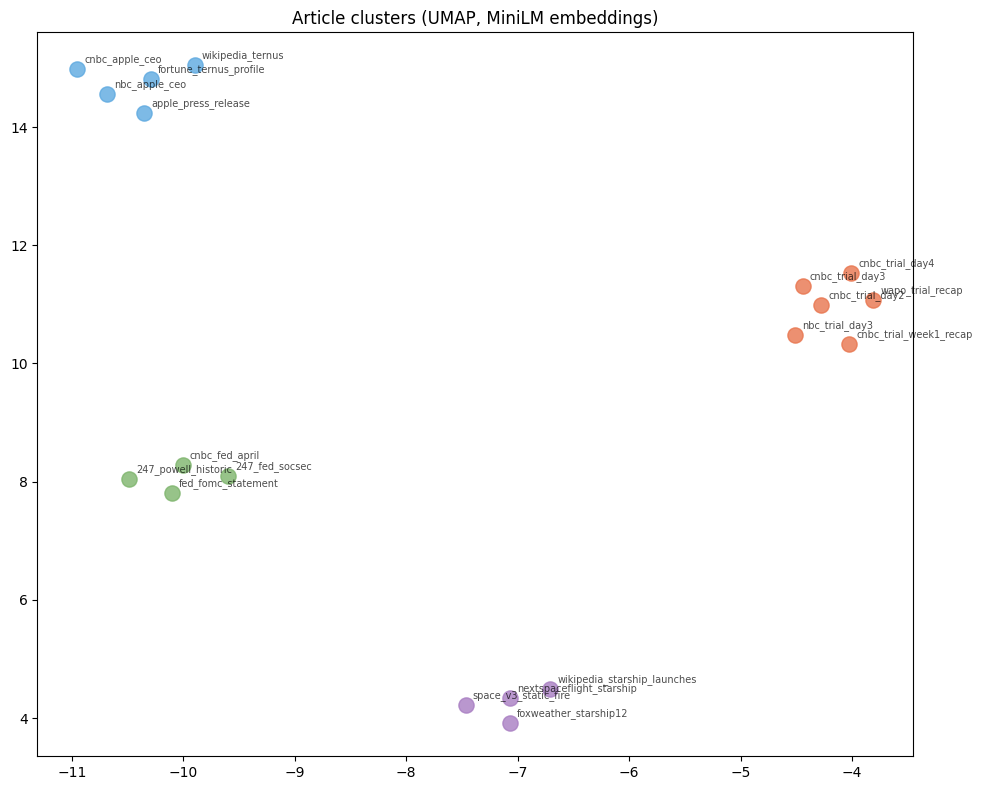

In [14]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# embeddings: shape (19, 384), already L2-normalized
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=5,        # small because dataset is small; use 15-30 at scale
    min_dist=0.1,
    metric='cosine',
    random_state=42,
)
coords_2d = reducer.fit_transform(embeddings)

# Color by ground-truth cluster
cluster_colors = {
    'musk_openai_trial':    '#E8744D',
    'apple_ceo_transition': '#5DA9E0',
    'fed_rate_decision':    '#7DB46C',
    'spacex_starship_12':   '#A87DC2',
}

fig, ax = plt.subplots(figsize=(10, 8))
for article, (x, y) in zip(ARTICLES, coords_2d):
    ax.scatter(x, y, color=cluster_colors[article['cluster']], s=120, alpha=0.8)
    ax.annotate(article['id'], (x, y), fontsize=7, alpha=0.7,
                xytext=(5, 5), textcoords='offset points')

ax.set_title('Article clusters (UMAP, MiniLM embeddings)')
plt.tight_layout()
plt.savefig('clusters_umap.png', dpi=120)

In [15]:
labels_060 = cluster_at_threshold(embeddings, 0.60)
for art, lbl in zip(ARTICLES, labels_060):
    print(f"{lbl}  {art['cluster']:30}  {art['id']}")

0  musk_openai_trial               cnbc_trial_day2
0  musk_openai_trial               cnbc_trial_day3
0  musk_openai_trial               cnbc_trial_day4
0  musk_openai_trial               cnbc_trial_week1_recap
0  musk_openai_trial               nbc_trial_day3
0  musk_openai_trial               wapo_trial_recap
1  apple_ceo_transition            apple_press_release
1  apple_ceo_transition            cnbc_apple_ceo
1  apple_ceo_transition            nbc_apple_ceo
1  apple_ceo_transition            fortune_ternus_profile
1  apple_ceo_transition            wikipedia_ternus
2  fed_rate_decision               fed_fomc_statement
3  fed_rate_decision               cnbc_fed_april
4  fed_rate_decision               247_powell_historic
3  fed_rate_decision               247_fed_socsec
5  spacex_starship_12              foxweather_starship12
5  spacex_starship_12              space_v3_static_fire
5  spacex_starship_12              wikipedia_starship_launches
5  spacex_starship_12              nex

In [ ]:
"""
Story-level LLM summarization for Brevio.

Architecture:
  - Input: a list of articles in the same cluster (one "story")
  - Output: a structured StorySummary with headline, summary, key points, entities
  - Model: gpt-4o-mini by default (cheap, fast, good enough)
  - Caching: by hash of article set, so re-clustering doesn't re-summarize
  - Output format: JSON via OpenAI's response_format

Usage:
    from story_summarizer import StorySummarizer

    summarizer = StorySummarizer(api_key=os.environ["OPENAI_API_KEY"])
    summary = summarizer.summarize_story(articles)
    print(summary.headline)
    print(summary.summary)
"""

from __future__ import annotations

import hashlib
import json
import logging
import os
import time
from dataclasses import dataclass, field, asdict
from typing import Any, Optional

from openai import OpenAI
from openai import APIError, RateLimitError, APITimeoutError


logger = logging.getLogger(__name__)


# ---------------------------------------------------------------------------
# Data structures
# ---------------------------------------------------------------------------

@dataclass
class StorySummary:
    """Output of summarizing one story (cluster of related articles)."""
    headline: str                # ~10 words, the canonical headline for the story
    summary: str                 # 60-120 words depending on content type
    key_points: list[str]        # 3-5 bullets, factual takeaways
    entities: list[str]          # named entities (people, orgs, products)
    source_count: int            # number of articles synthesized
    model: str                   # model used, for auditing
    input_tokens: int = 0
    output_tokens: int = 0
    cached: bool = False         # True if returned from cache, no API call

    def to_dict(self) -> dict:
        return asdict(self)


@dataclass
class StorySummarizerConfig:
    """All the knobs in one place."""
    model: str = "gpt-4o-mini"
    max_summary_words: int = 100      # for `summary` field
    max_headline_words: int = 12      # for `headline` field
    max_key_points: int = 5
    max_input_chars_per_article: int = 1500  # truncate long articles before sending
    timeout_seconds: float = 30.0
    max_retries: int = 3
    retry_initial_delay: float = 1.0  # exponential backoff base
    temperature: float = 0.2          # low — we want consistent factual summaries
    enable_cache: bool = True


# ---------------------------------------------------------------------------
# Caching
# ---------------------------------------------------------------------------

class _InMemoryCache:
    """
    Simple cache keyed on the set of article URLs in the story.
    Replace with Redis or DB-backed cache in production.
    """
    def __init__(self) -> None:
        self._store: dict[str, StorySummary] = {}

    def get(self, key: str) -> Optional[StorySummary]:
        return self._store.get(key)

    def set(self, key: str, value: StorySummary) -> None:
        self._store[key] = value

    def clear(self) -> None:
        self._store.clear()


def _cache_key_for_articles(articles: list[dict]) -> str:
    """
    Hash by sorted article URLs. Same set of articles → same cache key,
    regardless of order or processing.
    """
    urls = sorted(a.get("url", a.get("id", "")) for a in articles)
    payload = "|".join(urls)
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


# ---------------------------------------------------------------------------
# Prompt construction
# ---------------------------------------------------------------------------

_SYSTEM_PROMPT = """You are a news editor synthesizing coverage of a single story from multiple sources.

Your job: produce ONE concise, factual summary that captures what happened across all the articles provided.

CRITICAL RULES:
1. Only use information present in the source articles. Do not invent facts, numbers, quotes, or details.
2. If sources disagree on a fact, note the disagreement rather than picking one silently.
3. Lead with the actual finding or news, not the framing. "Anthropic released Claude X" not "Anthropic announced developments today."
4. Use neutral, factual language. No marketing voice, no editorializing.
5. Do not use phrases like "according to reports" or "sources say" — just state the facts.
6. Synthesize across sources. The summary should reflect ALL the articles, not just one.

Return your response as JSON matching the requested schema."""


def _build_user_prompt(articles: list[dict], cfg: StorySummarizerConfig) -> str:
    """Build the user-side prompt with article content."""
    article_blocks = []
    for i, a in enumerate(articles, 1):
        title = a.get("title", "(no title)")
        content = a.get("content", "")
        # Truncate to keep token costs predictable
        if len(content) > cfg.max_input_chars_per_article:
            content = content[: cfg.max_input_chars_per_article].rsplit(" ", 1)[0] + "..."
        url = a.get("url", "")
        block = f"[Source {i}] {title}\nURL: {url}\n\n{content}"
        article_blocks.append(block)

    sources_text = "\n\n---\n\n".join(article_blocks)

    schema_description = f"""Synthesize the following {len(articles)} articles about the same story.

Return JSON with these exact keys:
{{
  "headline": "string, max {cfg.max_headline_words} words, the canonical headline for the story",
  "summary": "string, max {cfg.max_summary_words} words, neutral factual summary synthesizing all sources",
  "key_points": ["3 to {cfg.max_key_points} short factual bullet strings"],
  "entities": ["list of named entities — people, organizations, products — mentioned across sources"]
}}

Articles:

{sources_text}"""

    return schema_description


# ---------------------------------------------------------------------------
# Validation / post-processing
# ---------------------------------------------------------------------------

def _word_count(s: str) -> int:
    return len(s.split())


def _validate_and_clean(
    raw: dict, cfg: StorySummarizerConfig
) -> tuple[dict, list[str]]:
    """
    Validate the LLM output. Returns (cleaned_dict, warnings).
    Doesn't raise — best-effort cleanup so a slightly-off response still works.
    """
    warnings: list[str] = []

    # Required keys with safe defaults
    headline = str(raw.get("headline", "")).strip()
    summary = str(raw.get("summary", "")).strip()
    key_points = raw.get("key_points", []) or []
    entities = raw.get("entities", []) or []

    # Word-count checks (warn, don't fail)
    if _word_count(headline) > cfg.max_headline_words + 3:
        warnings.append(
            f"headline exceeded word cap: {_word_count(headline)} > {cfg.max_headline_words}"
        )
    if _word_count(summary) > cfg.max_summary_words + 15:
        warnings.append(
            f"summary exceeded word cap: {_word_count(summary)} > {cfg.max_summary_words}"
        )

    # Type coerce
    if not isinstance(key_points, list):
        warnings.append("key_points was not a list, defaulting to empty")
        key_points = []
    if not isinstance(entities, list):
        warnings.append("entities was not a list, defaulting to empty")
        entities = []

    # Clamp list lengths
    key_points = [str(x).strip() for x in key_points][: cfg.max_key_points]
    entities = [str(x).strip() for x in entities][:20]

    # If headline is empty, derive from first sentence of summary
    if not headline and summary:
        warnings.append("headline was empty, derived from summary")
        headline = summary.split(".")[0][:80]

    return (
        {
            "headline": headline,
            "summary": summary,
            "key_points": key_points,
            "entities": entities,
        },
        warnings,
    )


# ---------------------------------------------------------------------------
# Main class
# ---------------------------------------------------------------------------

class StorySummarizer:
    """
    Generates synthesized summaries from a cluster of related articles.

    Cost note: at gpt-4o-mini prices (~$0.15 / 1M input, $0.60 / 1M output),
    a typical 4-article story summary costs roughly $0.001–0.003. At 300
    stories/day that's $0.30–0.90/day, $9–27/month.
    """

    def __init__(
        self,
        api_key: Optional[str] = None,
        config: Optional[StorySummarizerConfig] = None,
        client: Optional[OpenAI] = None,
        cache: Optional[Any] = None,
    ) -> None:
        self.config = config or StorySummarizerConfig()
        if client is not None:
            self.client = client
        else:
            self.client = OpenAI(
                api_key=api_key or os.environ.get("OPENAI_API_KEY"),
                timeout=self.config.timeout_seconds,
            )
        self.cache = cache if cache is not None else _InMemoryCache()

    # -----------------------------------------------------------------------
    # Public API
    # -----------------------------------------------------------------------

    def summarize_story(self, articles: list[dict]) -> StorySummary:
        """
        Summarize a single story (list of articles in the same cluster).

        Each article dict should have at minimum: 'title', 'content'.
        Optional: 'url', 'id'.
        """
        if not articles:
            raise ValueError("Cannot summarize empty article list")

        # Cache check
        cache_key = _cache_key_for_articles(articles) if self.config.enable_cache else None
        if cache_key:
            cached_result = self.cache.get(cache_key)
            if cached_result is not None:
                logger.debug("cache hit for %d-article story", len(articles))
                cached_result.cached = True
                return cached_result

        # Single-article story: still summarize, but the model has less to work with
        if len(articles) == 1:
            logger.debug("summarizing singleton story: %s", articles[0].get("id"))

        # Call OpenAI with retries
        response_data, usage = self._call_openai_with_retries(articles)

        # Validate & clean
        cleaned, warnings = _validate_and_clean(response_data, self.config)
        for w in warnings:
            logger.warning("summary cleanup: %s", w)

        result = StorySummary(
            headline=cleaned["headline"],
            summary=cleaned["summary"],
            key_points=cleaned["key_points"],
            entities=cleaned["entities"],
            source_count=len(articles),
            model=self.config.model,
            input_tokens=usage.get("input_tokens", 0),
            output_tokens=usage.get("output_tokens", 0),
            cached=False,
        )

        if cache_key:
            self.cache.set(cache_key, result)

        return result

    def summarize_stories_batch(
        self, stories: list[list[dict]]
    ) -> list[StorySummary]:
        """
        Summarize multiple stories. Sequential by default — switch to async
        if you need parallelism (OpenAI rate limits apply per minute).
        """
        results = []
        for i, articles in enumerate(stories):
            try:
                result = self.summarize_story(articles)
                results.append(result)
            except Exception as e:
                logger.error("failed to summarize story %d (%d articles): %s",
                             i, len(articles), e)
                # Append a stub so downstream code can detect the failure
                results.append(
                    StorySummary(
                        headline="(summarization failed)",
                        summary="",
                        key_points=[],
                        entities=[],
                        source_count=len(articles),
                        model=self.config.model,
                    )
                )
        return results

    # -----------------------------------------------------------------------
    # Internal: OpenAI call with retries
    # -----------------------------------------------------------------------

    def _call_openai_with_retries(
        self, articles: list[dict]
    ) -> tuple[dict, dict]:
        """
        Returns (parsed_response_dict, usage_dict).
        Retries on transient errors; gives up after max_retries.
        """
        user_prompt = _build_user_prompt(articles, self.config)

        last_error: Optional[Exception] = None
        for attempt in range(self.config.max_retries):
            try:
                response = self.client.chat.completions.create(
                    model=self.config.model,
                    messages=[
                        {"role": "system", "content": _SYSTEM_PROMPT},
                        {"role": "user", "content": user_prompt},
                    ],
                    response_format={"type": "json_object"},
                    temperature=self.config.temperature,
                )

                content = response.choices[0].message.content or "{}"
                parsed = json.loads(content)

                usage = {
                    "input_tokens": response.usage.prompt_tokens if response.usage else 0,
                    "output_tokens": response.usage.completion_tokens if response.usage else 0,
                }
                return parsed, usage

            except (RateLimitError, APITimeoutError) as e:
                # Transient — back off and retry
                last_error = e
                delay = self.config.retry_initial_delay * (2 ** attempt)
                logger.warning(
                    "transient OpenAI error on attempt %d/%d: %s. retrying in %.1fs",
                    attempt + 1, self.config.max_retries, e, delay,
                )
                time.sleep(delay)

            except json.JSONDecodeError as e:
                # Model returned malformed JSON despite json_object mode
                # Could be temperature too high or token cutoff. Retry once.
                last_error = e
                logger.warning("malformed JSON from OpenAI: %s. retrying", e)
                time.sleep(self.config.retry_initial_delay)

            except APIError as e:
                # 4xx / 5xx — sometimes transient, sometimes not. Try once more.
                last_error = e
                if attempt < self.config.max_retries - 1:
                    delay = self.config.retry_initial_delay * (2 ** attempt)
                    logger.warning("OpenAI API error: %s. retrying in %.1fs", e, delay)
                    time.sleep(delay)
                else:
                    raise

        raise RuntimeError(
            f"summarization failed after {self.config.max_retries} attempts. "
            f"last error: {last_error}"
        )


# ---------------------------------------------------------------------------
# Demo / smoke test
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    """
    Quick smoke test using the test_articles fixture from clustering.
    Run with: OPENAI_API_KEY=sk-... python story_summarizer.py
    """
    logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

    # Group articles by cluster (this would be your clusterer's output in production)
    from collections import defaultdict
    clusters = defaultdict(list)
    for a in ARTICLES:
        clusters[a["cluster"]].append(a)

    summarizer = StorySummarizer()

    print(f"\nSummarizing {len(clusters)} stories from {len(ARTICLES)} articles\n")
    print("=" * 72)

    for cluster_id, articles in clusters.items():
        print(f"\n## Cluster: {cluster_id} ({len(articles)} articles)")
        result = summarizer.summarize_story(articles)
        print(f"\nHeadline:  {result.headline}")
        print(f"\nSummary:   {result.summary}")
        print(f"\nKey points:")
        for point in result.key_points:
            print(f"  - {point}")
        print(f"\nEntities:  {', '.join(result.entities[:10])}")
        print(f"\nTokens:    {result.input_tokens} in, {result.output_tokens} out")
        print("-" * 72)

    # Verify caching works
    print("\n## Cache verification (re-running first cluster)")
    first_cluster = list(clusters.values())[0]
    cached_result = summarizer.summarize_story(first_cluster)
    print(f"Cached: {cached_result.cached}")
    print(f"Tokens: {cached_result.input_tokens} in, {cached_result.output_tokens} out (should be 0)")